In [1]:
import pandas as pd
import numpy as np
from coffea import util
import itertools
import os
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
from hist import plot
hep.style.use("CMS")

In [2]:
IOVs = ['2016all']#, '2016', '2017', '2018']
useOldHTcut = False
useOldTaggers = False
oldTaggerstr = ''
oldHTstr = ''
if useOldHTcut:
    oldHTstr = '_oldHTcut'
if useOldTaggers:
    oldTaggerstr = '_oldBTag'

# analysis categories #

label_dict = util.load(f'../outputs/QCD_2016_15to7000.coffea')['analysisCategories']
label_to_int_dict = {label: i for i, label in label_dict.items()}

# signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
# pretag_cats = [ i for label, i in label_to_int_dict.items() if 'pret' in label]

print(label_dict)

{0: 'at0bcen', 1: 'at0bfwd', 2: 'at1bcen', 3: 'at1bfwd', 4: 'at2bcen', 5: 'at2bfwd', 6: 'pret0bcen', 7: 'pret0bfwd', 8: 'pret1bcen', 9: 'pret1bfwd', 10: 'pret2bcen', 11: 'pret2bfwd', 12: '2t0bcen', 13: '2t0bfwd', 14: '2t1bcen', 15: '2t1bfwd', 16: '2t2bcen', 17: '2t2bfwd'}


In [3]:
lumi = {
    "2016APV": 19800.,
    "2016": 16120., #35920 - 19800
    "2016all": 35920,
    "2017": 41530.,
    "2018": 59740.,
    "Full": 137190.
}

# qcd_xs = 1373000000.0 #pb From https://cms-gen-dev.cern.ch/xsdb

In [4]:
directories = [
    'images/png/closureTestQCD/2016all',
    'images/png/closureTestQCD/2016APV',
    'images/png/closureTestQCD/2016',
    'images/png/closureTestQCD/2017',
    'images/png/closureTestQCD/2018',
    'images/png/closureTestQCD/Full',
    'images/pdf/closureTestQCD/2016all',
    'images/pdf/closureTestQCD/2016APV',
    'images/pdf/closureTestQCD/2016',
    'images/pdf/closureTestQCD/2017',
    'images/pdf/closureTestQCD/2018',
    'images/pdf/closureTestQCD/Full'
]


for path in directories:
    if not os.path.exists(path):
        os.makedirs(path)

In [5]:
# tagger='DeepAK8 top tagger'
tagger='CMS top tagger v2'

coffea_dir = '../outputs/'
coffeaFiles = {
    "unweighted": {
        "2016APV": {
            "300to470": coffea_dir+'QCD_2016APV_300to470_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "470to600": coffea_dir+'QCD_2016APV_470to600_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "600to800": coffea_dir+'QCD_2016APV_600to800_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "800to1000": coffea_dir+'QCD_2016APV_800to1000_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016APV_1000to1400_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016APV_1400to1800_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016APV_1800to2400_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016APV_2400to3200_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016APV_3200toInf_noSyst'+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "300to470": coffea_dir+'QCD_2016_300to470_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "470to600": coffea_dir+'QCD_2016_470to600_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "600to800": coffea_dir+'QCD_2016_600to800_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "800to1000": coffea_dir+'QCD_2016_800to1000_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016_1000to1400_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016_1400to1800_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016_1800to2400_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016_2400to3200_noSyst'+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016_3200toInf_noSyst'+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": coffea_dir+'QCD_2017'+oldHTstr+oldTaggerstr+'.coffea',
        "2018": coffea_dir+'QCD_2018'+oldHTstr+oldTaggerstr+'.coffea'
    },
    "weighted": {
        "2016APV": {
            "300to470": coffea_dir+'QCD_2016APV_300to470_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "470to600": coffea_dir+'QCD_2016APV_470to600_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "600to800": coffea_dir+'QCD_2016APV_600to800_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "800to1000": coffea_dir+'QCD_2016APV_800to1000_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016APV_1000to1400_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016APV_1400to1800_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016APV_1800to2400_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016APV_2400to3200_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016APV_3200toInf_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2016": {
            "300to470": coffea_dir+'QCD_2016_300to470_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "470to600": coffea_dir+'QCD_2016_470to600_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "600to800": coffea_dir+'QCD_2016_600to800_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "800to1000": coffea_dir+'QCD_2016_800to1000_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1000to1400": coffea_dir+'QCD_2016_1000to1400_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1400to1800": coffea_dir+'QCD_2016_1400to1800_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "1800to2400": coffea_dir+'QCD_2016_1800to2400_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "2400to3200": coffea_dir+'QCD_2016_2400to3200_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
            "3200toInf": coffea_dir+'QCD_2016_3200toInf_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea'
        },
        "2017": coffea_dir+'QCD_2017_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea',
        "2018": coffea_dir+'QCD_2018_noSyst_bkgest'+oldHTstr+oldTaggerstr+'.coffea'
    }
}

In [6]:
Cutflow = util.load(coffeaFiles['weighted']['2016']['3200toInf'])['cutflow']
Cutflow

defaultdict_accumulator(int,
                        {'all events': 996000,
                         'sumw': 996000.0,
                         'Passed HT Cut': 996000,
                         'Passed Loose Jet ID': 996000,
                         'Passed pT,y Cut': 996000,
                         '>= 2 AK8 Jets': 992562,
                         '>= one TTbar': 992562,
                         'Passed dPhi Cut': 992133,
                         'Good Subjets': 951998,
                         'at0bcen': 43624,
                         'at0bfwd': 5415,
                         'at1bcen': 10973,
                         'at1bfwd': 1288,
                         'at2bcen': 721,
                         'at2bfwd': 57,
                         'pret0bcen': 18839,
                         'pret0bfwd': 2038,
                         'pret1bcen': 5137,
                         'pret1bfwd': 508,
                         'pret2bcen': 320,
                         'pret2bfwd': 24,
           

In [12]:
IOV = '2016all'
linearStr = ''
binstr = ''
pullstr = ''
xaxis = 'ttbarmass_fine'
useCats = False
Linear = False
Pull = False

sig_apv, sig_noapv = {}, {}
bkg_apv, bkg_noapv = {}, {}
sig_SF_apv, sig_SF_noapv = {'2016APV':{}, '2016':{}}, {'2016APV':{}, '2016':{}}
bkg_SF_apv, bkg_SF_noapv = {'2016APV':{}, '2016':{}}, {'2016APV':{}, '2016':{}}

# Calculate a scale factor from XSDB pythia gen cross section and gen lumi (xs)*(L)

# ---- From XSDB for UL ---- #
qcd_xs = {
    "300to470": 6806.0,
    "470to600": 551.2,
    "600to800": 156.7,
    "800to1000": 26.25,
    "1000to1400": 7.465,
    "1400to1800": 0.6487,
    "1800to2400": 0.08734,
    "2400to3200": 0.005237,
    "3200toInf": 0.0001352
}

# ---- From xs values in 2016AN reported for QCD ---- #
# qcd_xs = {
#     "300to470": 7823.0,
#     "470to600": 648.2,
#     "600to800": 186.9,
#     "800to1000": 32.293,
#     "1000to1400": 9.4183,
#     "1400to1800": 0.84265,
#     "1800to2400": 0.12163,
#     "2400to3200": 0.00682981,
#     "3200toInf": 0.000165445
# }


for pt in ['300to470', '470to600', '600to800', '800to1000', '1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']:
    
    sig_apv[pt] = util.load(coffeaFiles['unweighted']['2016APV'][pt])
    sig_noapv[pt] = util.load(coffeaFiles['unweighted']['2016'][pt])
    bkg_apv[pt] = util.load(coffeaFiles['weighted']['2016APV'][pt])
    bkg_noapv[pt] = util.load(coffeaFiles['weighted']['2016'][pt])
    
    
    sig_SF_apv['2016APV'][pt] = lumi['2016APV'] * qcd_xs[pt] / sig_apv[pt]['cutflow']['all events']
    sig_SF_noapv['2016'][pt] = lumi['2016'] * qcd_xs[pt] / sig_noapv[pt]['cutflow']['all events']
    bkg_SF_apv['2016APV'][pt] = lumi['2016APV'] * qcd_xs[pt] / bkg_apv[pt]['cutflow']['all events']
    bkg_SF_noapv['2016'][pt] = lumi['2016'] * qcd_xs[pt] / bkg_noapv[pt]['cutflow']['all events']
    
    
    # print(sig_apv[pt]['cutflow']['sumw'])
    

if 'fine' not in xaxis:
    binstr = '_wideBins'
      

# QCD Closure of All 2016:

/opt/conda/lib/python3.8/site-packages/hist/basehist.py:324: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


images/png/closureTestQCD/2016all/closureTest_inclusive.png


/tmp/ipykernel_159/2701924364.py:283: UserWarning: Glyph 9 (	) missing from current font.
  plt.savefig(savefilename)
/tmp/ipykernel_159/2701924364.py:284: UserWarning: Glyph 9 (	) missing from current font.
  plt.savefig(savefilename.replace('png', 'pdf'))
/tmp/ipykernel_159/2701924364.py:284: UserWarning: Glyph 9 (	) missing from current font.
  plt.savefig(savefilename.replace('png', 'pdf'))
/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


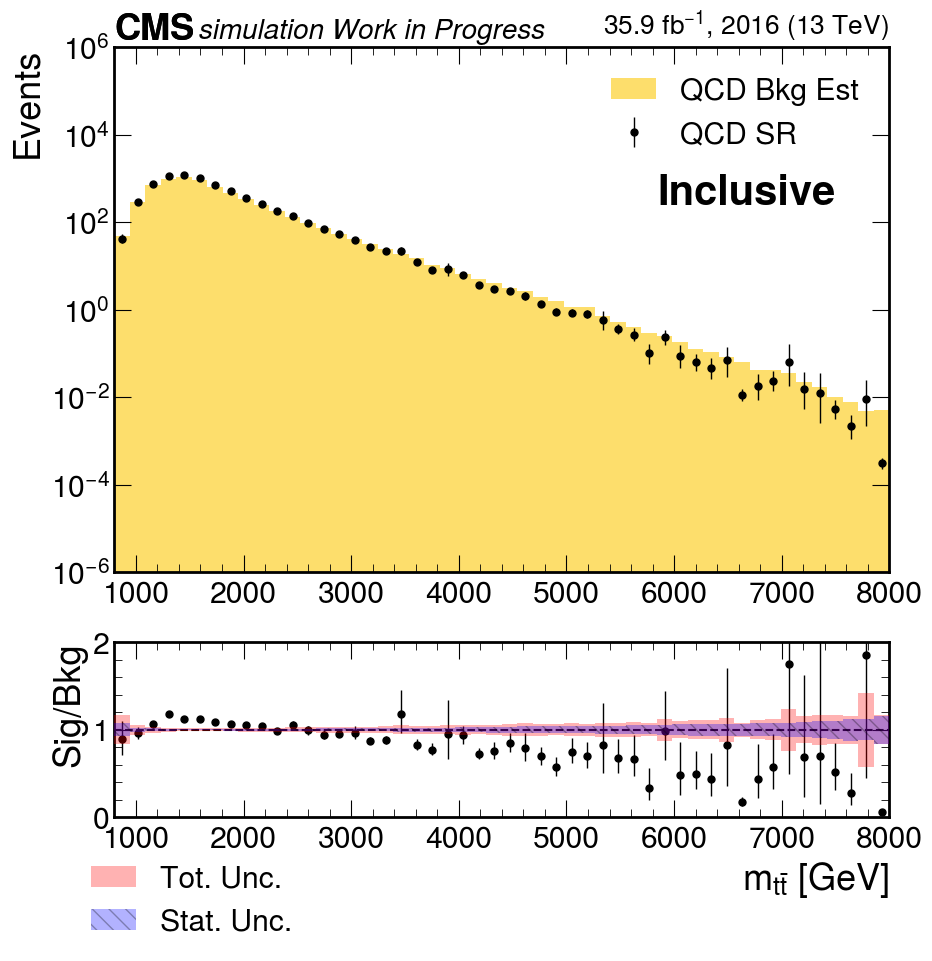

In [13]:
if useCats:
    for cat in ['0bcen', '0bfwd', '1bcen', '1bfwd', '2bcen', '2bfwd']:

        fig, (ax1, ax2) = plt.subplots(nrows=2, height_ratios=[3, 1])
        Text = f'\tWork in Progress'
        hep.cms.label('       '+Text, data=False, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year='2016', loc=0, fontsize=20, ax=ax1)
        plt.text(0.8, 0.7, cat, fontsize=30, fontweight='bold', transform=ax1.transAxes)
        

        signal_cats = [label_to_int_dict['2t'+cat]] #[ i for label, i in label_to_int_dict.items() if '2t' in label]
        pretag_cats = [label_to_int_dict['pret'+cat]] #[ i for label, i in label_to_int_dict.items() if 'pret' in label]
        antitag_cats = [label_to_int_dict['at'+cat]] #[ i for label, i in label_to_int_dict.items() if 'pret' in label]

        
        hsig_apv = sig_apv['300to470'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['300to470']
        hbkg_apv = bkg_apv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_apv['2016APV']['300to470']
        hanti_apv = sig_apv['300to470'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['300to470']
        hpre_apv = sig_apv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['300to470']
        hsig_noapv = sig_noapv['300to470'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['300to470']
        hbkg_noapv = bkg_noapv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_noapv['2016']['300to470']
        hanti_noapv = sig_noapv['300to470'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['300to470']
        hpre_noapv = sig_noapv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['300to470']
        
        hsig_apv_unscaled = sig_apv['300to470'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hbkg_apv_unscaled = bkg_apv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hanti_apv_unscaled = sig_apv['300to470'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hpre_apv_unscaled = sig_apv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hsig_noapv_unscaled = sig_noapv['300to470'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hbkg_noapv_unscaled = bkg_noapv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hanti_noapv_unscaled = sig_noapv['300to470'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hpre_noapv_unscaled = sig_noapv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]


        for pt in ['470to600', '600to800', '800to1000', '1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']:
            hsig_apv += sig_apv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
            hbkg_apv += bkg_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_apv['2016APV'][pt]
            hanti_apv += sig_apv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
            hpre_apv += sig_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
            hsig_noapv += sig_noapv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
            hbkg_noapv += bkg_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_noapv['2016'][pt]
            hanti_noapv += sig_noapv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
            hpre_noapv += sig_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
            
            hsig_apv_unscaled += sig_apv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}]
            hbkg_apv_unscaled += bkg_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
            hanti_apv_unscaled += sig_apv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}]
            hpre_apv_unscaled += sig_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
            hsig_noapv_unscaled += sig_noapv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}]
            hbkg_noapv_unscaled += bkg_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
            hanti_noapv_unscaled += sig_noapv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}]
            hpre_noapv_unscaled += sig_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
                
        hsig = hsig_noapv + hsig_apv
        hbkg = hbkg_noapv + hbkg_apv
        hanti = hanti_noapv + hanti_apv
        hpre = hpre_noapv + hpre_apv
        
        hsig_unscaled = hsig_noapv_unscaled + hsig_apv_unscaled
        hbkg_unscaled = hbkg_noapv_unscaled + hbkg_apv_unscaled
        hanti_unscaled = hanti_noapv_unscaled + hanti_apv_unscaled
        hpre_unscaled = hpre_noapv_unscaled + hpre_apv_unscaled
        
        Ndenom = hanti_unscaled.values()
        mistag = hbkg_unscaled / hpre_unscaled.values()
        term1 = np.ones(len(hpre_unscaled.values()))/hpre_unscaled.values()
        term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
        Errs = hbkg_unscaled.values()*np.sqrt( term1 + term2 )
        # Ndenom = hanti.values()
        # mistag = hbkg / hpre.values()
        # term1 = np.ones(len(hpre.values()))/hpre.values()
        # term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
        # Errs = hbkg.values()*np.sqrt( term1 + term2 )
        Height = Errs * 2
        
        Bottom = hbkg.values() - Errs
        
        hep.histplot(hsig, histtype='errorbar', ax=ax1, color='black', label='QCD SR')
        hep.histplot(hbkg, histtype='fill', ax=ax1, color='xkcd:pale gold', label='QCD Bkg Est')
        
        ax1.set_ylabel('Events')        
        ax1.set_yscale('log')
        ax1.set_ylim(1e-6, 1e6)
        ax1.set_xlim(800,8000)
        ax2.set_xlim(800,8000)
            
        ax1.set_xlabel('')
        ax1.legend()
        
        ratio_plot =  (hsig) / (hbkg.values())
        errs = ratio_plot.values() * np.sqrt( 1./(hsig_unscaled.values()) + (Errs**2/hbkg_unscaled.values()**2) ) 
        errs_stat = 1./np.sqrt(hbkg_unscaled.values()) #np.sqrt(hsig_unscaled.values())/hbkg_unscaled.values()
        # errs = ratio_plot.values() * np.sqrt( 1./(hsig.values()) + (Errs**2/hbkg.values()**2) ) 
        # errs_stat = np.sqrt(hsig.values())/hbkg.values()
    
        if 'ttbarmass' in xaxis:
            Edges = hbkg.axes['ttbarmass'].edges
        elif 'jetp' in xaxis:
            Edges = hbkg.axes['jetp'].edges
        else:
            Edges = hbkg.axes[xaxis].edges
            
        # ax1.bar(x = Edges[:-1],
        #        height=Height,
        #        bottom=Bottom,
        #        width = np.diff(Edges), align='edge', hatch='///', edgecolor='gray',
        #        linewidth=0, facecolor='none', alpha=0.8,
        #        zorder=10, label='Stat. Unc.')
        

        ax2.bar(x = Edges[:-1],
           height=(2.*(errs+errs_stat)),
           bottom=(np.ones_like(ratio_plot.values()) - errs - errs_stat),
           width = np.diff(Edges), align='edge', edgecolor='black',
           linewidth=0, facecolor='red', alpha=0.3,
           zorder=10, label='Tot. Unc.')

        ax2.bar(x = Edges[:-1],
               height=(2.*errs_stat),
               bottom=(np.ones_like(ratio_plot.values()) - errs_stat),
               width = np.diff(Edges), align='edge', hatch='\\\\', edgecolor='black',
               linewidth=0, facecolor='blue', alpha=0.3,
               zorder=10, label='Stat. Unc.')

        legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
        hep.histplot(ratio_plot, ax=ax2, histtype='errorbar', color='black')
        ax2.set_ylim(0,2)
        ax2.axhline(1, color='black', ls='--')
        ax2.set_ylabel('Sig/Bkg')
            
        if Linear:
            ax1.set_yscale('linear')
            ax1.set_ylim(0, 0.20)
            ax1.set_xlim(800,8000)
            ax2.set_xlim(800,8000)
            linearStr = '_LINEAR'
        
        savefilename = f'images/png/closureTestQCD/{IOV}/closureTest_{cat}{linearStr}{binstr}{pullstr}{oldHTstr}.png'
        print(savefilename)
        plt.savefig(savefilename)
        plt.savefig(savefilename.replace('png', 'pdf'))
        plt.show()
else:
    fig, (ax1, ax2) = plt.subplots(nrows=2, height_ratios=[3, 1])

    Text = f'simulation\nWork in Progress'
    if Linear:
        hep.cms.label('       '+Text, data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year='2016', loc=2, fontsize=20, ax=ax1)
    else:
        Text = f'simulation\tWork in Progress'
        hep.cms.label('', data=True, lumi='{0:0.1f}'.format(lumi[IOV]/1000.), year='2016', loc=0, fontsize=20, ax=ax1)
        hep.cms.text(Text, loc=0, fontsize=20, ax=ax1)

    plt.text(0.7, 0.7, 'Inclusive', fontsize=30, fontweight='bold', transform=ax1.transAxes)

    signal_cats = [ i for label, i in label_to_int_dict.items() if '2t' in label]
    pretag_cats = [ i for label, i in label_to_int_dict.items() if 'pret' in label]
    antitag_cats = [ i for label, i in label_to_int_dict.items() if 'at' in label]

    hsig_apv = sig_apv['300to470'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['300to470']
    hbkg_apv = bkg_apv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_apv['2016APV']['300to470']
    hanti_apv = sig_apv['300to470'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['300to470']
    hpre_apv = sig_apv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV']['300to470']
    hsig_noapv = sig_noapv['300to470'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['300to470']
    hbkg_noapv = bkg_noapv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_noapv['2016']['300to470']
    hanti_noapv = sig_noapv['300to470'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['300to470']
    hpre_noapv = sig_noapv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016']['300to470']
    
    hsig_apv_unscaled = sig_apv['300to470'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}]
    hbkg_apv_unscaled = bkg_apv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
    hanti_apv_unscaled = sig_apv['300to470'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}]
    hpre_apv_unscaled = sig_apv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
    hsig_noapv_unscaled = sig_noapv['300to470'][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}]
    hbkg_noapv_unscaled = bkg_noapv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
    hanti_noapv_unscaled = sig_noapv['300to470'][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}]
    hpre_noapv_unscaled = sig_noapv['300to470'][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]

    for pt in ['470to600', '600to800', '800to1000', '1000to1400', '1400to1800', '1800to2400', '2400to3200', '3200toInf']:
        hsig_apv += sig_apv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
        hbkg_apv += bkg_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_apv['2016APV'][pt]
        hanti_apv += sig_apv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
        hpre_apv += sig_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_apv['2016APV'][pt]
        hsig_noapv += sig_noapv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
        hbkg_noapv += bkg_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * bkg_SF_noapv['2016'][pt]
        hanti_noapv += sig_noapv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
        hpre_noapv += sig_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}] * sig_SF_noapv['2016'][pt]
        
        hsig_apv_unscaled += sig_apv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hbkg_apv_unscaled += bkg_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hanti_apv_unscaled += sig_apv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hpre_apv_unscaled += sig_apv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hsig_noapv_unscaled += sig_noapv[pt][xaxis][{'anacat':signal_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hbkg_noapv_unscaled += bkg_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hanti_noapv_unscaled += sig_noapv[pt][xaxis][{'anacat':antitag_cats, 'systematic':'nominal'}][{'anacat':sum}]
        hpre_noapv_unscaled += sig_noapv[pt][xaxis][{'anacat':pretag_cats, 'systematic':'nominal'}][{'anacat':sum}]
                
    hsig = hsig_noapv + hsig_apv
    hbkg = hbkg_noapv + hbkg_apv
    hanti = hanti_noapv + hanti_apv
    hpre = hpre_noapv + hpre_apv
    
    hsig_unscaled = hsig_noapv_unscaled + hsig_apv_unscaled
    hbkg_unscaled = hbkg_noapv_unscaled + hbkg_apv_unscaled
    hanti_unscaled = hanti_noapv_unscaled + hanti_apv_unscaled
    hpre_unscaled = hpre_noapv_unscaled + hpre_apv_unscaled

    Ndenom = hanti_unscaled.values()
    mistag = hbkg_unscaled / hpre_unscaled.values()
    term1 = np.ones(len(hpre_unscaled.values()))/hpre_unscaled.values()
    term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
    Errs = hbkg_unscaled.values()*np.sqrt( term1 + term2 )
    # Ndenom = hanti.values()
    # mistag = hbkg / hpre.values()
    # term1 = np.ones(len(hpre.values()))/hpre.values()
    # term2 = (np.ones(len(mistag.values()))-mistag.values())/(Ndenom*mistag.values())
    # Errs = hbkg.values()*np.sqrt( term1 + term2 )
    # Height = Errs * 2

    Bottom = hbkg.values() - Errs

    hep.histplot(hsig, histtype='errorbar', ax=ax1, color='black', label='QCD SR')
    hep.histplot(hbkg, histtype='fill', ax=ax1, color='xkcd:pale gold', label='QCD Bkg Est')

    ax1.legend()
    ax1.set_ylabel('Events')
    ax1.set_yscale('log')
    ax1.set_ylim(10**(-6), 10**6)
    ax1.set_xlim(800,8000)
    ax2.set_xlim(800,8000)
    ax1.set_xlabel('')

    ratio_plot =  hsig / hbkg.values()
    errs = ratio_plot.values() * np.sqrt( 1./(hsig_unscaled.values()) + (Errs**2/hbkg_unscaled.values()**2) ) 
    errs_stat = np.sqrt(hsig_unscaled.values())/hbkg_unscaled.values()
    # errs = ratio_plot.values() * np.sqrt( (1./hbkg.values()*ratio_plot.values()) + (Errs**2/hbkg.values()**2) ) 
    # errs_stat = ratio_plot.values() * np.sqrt( 1./(hbkg.values()*ratio_plot.values()) + 1./(hbkg.values()) )
    # errs_stat = 1./hbkg.values()
    
    
    if 'ttbarmass' in xaxis:
        Edges = hbkg.axes['ttbarmass'].edges
    elif 'jetp' in xaxis:
        Edges = hbkg.axes['jetp'].edges
    else:
        Edges = hbkg.axes[xaxis].edges
        
    # ax1.bar(x = Edges[:-1],
    #            height=Height,
    #            bottom=Bottom,
    #            width = np.diff(Edges), align='edge', hatch='///', edgecolor='gray',
    #            linewidth=0, facecolor='none', alpha=0.8,
    #            zorder=10, label='Bkg. Est. Unc.')

    ax2.bar(x = Edges[:-1],
           height=(2.*(errs+errs_stat)),
           bottom=(np.ones_like(ratio_plot.values()) - errs - errs_stat),
           width = np.diff(Edges), align='edge', edgecolor='black',
           linewidth=0, facecolor='red', alpha=0.3,
           zorder=10, label='Tot. Unc.')

    ax2.bar(x = Edges[:-1],
           height=(2.*errs_stat),
           bottom=(np.ones_like(ratio_plot.values()) - errs_stat),
           width = np.diff(Edges), align='edge', hatch='\\\\', edgecolor='black',
           linewidth=0, facecolor='blue', alpha=0.3,
           zorder=10, label='Stat. Unc.')

    legend2 = plt.legend(bbox_to_anchor =(0.1,-0.85), loc='lower center')
    hep.histplot(ratio_plot, ax=ax2, histtype='errorbar', color='black')
    ax2.set_ylim(0,2)
    ax2.axhline(1, color='black', ls='--')
    ax2.set_ylabel('Sig/Bkg')

    
    if Linear:
        ax1.set_yscale('linear')
        ax1.set_ylim(0, 0.20)
        ax1.set_xlim(800,8000)
        ax2.set_xlim(800,8000)
        linearStr = '_LINEAR'
    
    savefilename = f'images/png/closureTestQCD/{IOV}/closureTest_inclusive{linearStr}{binstr}{pullstr}{oldHTstr}.png'
    print(savefilename)
    plt.savefig(savefilename)
    plt.savefig(savefilename.replace('png', 'pdf'))
    plt.show()

# QCD Closure of Full Luminosity: